In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from transformers import AutoTokenizer, AutoModelForCausalLM

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Libraries imported successfully.
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# ==============================
# QWEN SENTIFIVE EXPERIMENT
# ==============================

MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

DATA_PATH = "/kaggle/input/datasets/amermahbub01/sentifive"

N_SAMPLES = 3000
RANDOM_STATE = 42

MAX_NEW_TOKENS = 10

print("Model:", MODEL_ID)
print("Dataset:", DATA_PATH)
print("Evaluation samples:", N_SAMPLES)
print("Random state:", RANDOM_STATE)
print("Max new tokens:", MAX_NEW_TOKENS)

Model: Qwen/Qwen2.5-3B-Instruct
Dataset: /kaggle/input/datasets/amermahbub01/sentifive
Evaluation samples: 3000
Random state: 42
Max new tokens: 10


In [7]:
df = pd.read_csv("/kaggle/input/datasets/amermahbub01/sentifive/SentiFive.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully.
Shape: (31411, 2)

Columns:
['data', 'title']

First 5 rows:


,data,title
0,থিওরি অফ রিলেটিভিটির প্রেক্ষিতে বাংলা ভাষার এ...,নিশ্চিত ইতিবাচক
1,এডমিনকে অনুরোধ করব যারা এসব কাজ করে দুই বাংলার...,নিরপেক্ষ
2,খাদ্যগলিডেকার্স লেনে ভোজনচর্চা,নিরপেক্ষ
3,আদনান তোর বৌয়ের ভোদা খাবো খুব মিষ্টি রস বেরোয...,নিশ্চিত নেতিবাচক
4,কে কে আমার ভিডিও লাইক করলে,নিরপেক্ষ


In [8]:
print("DATASET INFORMATION")
print("=" * 60)

print("Shape:", df.shape)
print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSample comments:")
for i in range(5):
    print(f"\n{i + 1}. {df.iloc[i]['data']}")

DATASET INFORMATION
Shape: (31411, 2)

Column data types:
data     object
title    object
dtype: object

Missing values:
data     0
title    0
dtype: int64

Sample comments:

1.  থিওরি অফ রিলেটিভিটির প্রেক্ষিতে বাংলা ভাষার এই বৈচিত্রতে তো ভাষা সমৃদ্ধই হয় এটা জ্ঞান দেবার জায়গা নয় আর তার চেষ্টাও করছিনা কিন্তু লেখার যুক্তির সাথে স্থানীয় প্রচলিত শব্দের যে মাধুর্য সেটাকে গ্রহণ করতে অসুবিধা কোথায়  অন্তত বোঝার জন্যেও পরিবর্তে ব্যঙ্গ করাটা সম্ভবত শিষ্টাচারের মধ্যে পরেনা পশ্চিমবঙ্গের বিভিন্ন জেলাতে তো বটেই এমনকি খাস কলকাতার যে বাংলা তাতেও তো বহু বৈচিত্র আছে সবগুলো যে খুব শ্রুতি মাধুর্যে ভরা তাও তো নয় তাহলে এই অসহিষ্ণুতা কেনো সেটা সত্যি বোঝা যায়না এছাড়াও দুর্ভাগ্যবশত অতি অল্প কিছু লেখামন্তব্য এতটাই কদর্য যে মনে হয় মাতৃভাষার এর থেকে বড় অপমান আর কোনো ভাবে করা যায়না অনুরোধ করি যে আশাকরি এইটুকু ভেবে অত্যন্ত লেখার সময় তারা সংযত থাকবেন  যারা নিজের মাতৃভাষাকে ভালোবাসেন আর শ্রদ্ধা করেন অনুরোধ সকলের কাছে নমস্কার

2. এডমিনকে অনুরোধ করব যারা এসব কাজ করে দুই বাংলার মানুষের মাঝে সম্প্রীতি নষ্ট করতে তৎপর তাদে

In [9]:
print("UNIQUE SENTIMENT LABELS")
print("=" * 60)

print(df["title"].value_counts())

print("\nNumber of unique labels:", df["title"].nunique())

UNIQUE SENTIMENT LABELS
title
নিশ্চিত নেতিবাচক    6780
নিশ্চিত ইতিবাচক     6537
নিরপেক্ষ            6453
কিছুটা নেতিবাচক     6006
কিছুটা ইতিবাচক      5635
Name: count, dtype: int64

Number of unique labels: 5


In [10]:
label_mapping = {
    "নিশ্চিত নেতিবাচক": 0,
    "কিছুটা নেতিবাচক": 1,
    "নিরপেক্ষ": 2,
    "কিছুটা ইতিবাচক": 3,
    "নিশ্চিত ইতিবাচক": 4
}

id_to_label = {
    0: "Strongly Negative",
    1: "Slightly Negative",
    2: "Neutral",
    3: "Slightly Positive",
    4: "Strongly Positive"
}

df["label_id"] = df["title"].map(label_mapping)

print("Label mapping:")
for label_id, label_name in id_to_label.items():
    bengali_label = [k for k, v in label_mapping.items() if v == label_id][0]
    print(f"{label_id} = {label_name} ({bengali_label})")

print("\nLabel counts:")
print(df["label_id"].value_counts().sort_index())

Label mapping:
0 = Strongly Negative (নিশ্চিত নেতিবাচক)
1 = Slightly Negative (কিছুটা নেতিবাচক)
2 = Neutral (নিরপেক্ষ)
3 = Slightly Positive (কিছুটা ইতিবাচক)
4 = Strongly Positive (নিশ্চিত ইতিবাচক)

Label counts:
label_id
0    6780
1    6006
2    6453
3    5635
4    6537
Name: count, dtype: int64


In [11]:
print("DATA INTEGRITY CHECK")
print("=" * 60)

print("Missing comments:", df["data"].isnull().sum())
print("Missing original labels:", df["title"].isnull().sum())
print("Missing label IDs:", df["label_id"].isnull().sum())

assert df["data"].isnull().sum() == 0
assert df["title"].isnull().sum() == 0
assert df["label_id"].isnull().sum() == 0

assert df["label_id"].isin([0, 1, 2, 3, 4]).all()

print("\n✓ No missing comments")
print("✓ No missing labels")
print("✓ No unmapped labels")
print("✓ All label IDs are valid")

DATA INTEGRITY CHECK
Missing comments: 0
Missing original labels: 0
Missing label IDs: 0

✓ No missing comments
✓ No missing labels
✓ No unmapped labels
✓ All label IDs are valid


In [12]:
train_df, eval_df = train_test_split(
    df,
    test_size=N_SAMPLES,
    stratify=df["label_id"],
    random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

print("DATA SPLIT")
print("=" * 60)

print("Demonstration pool:", len(train_df))
print("Evaluation set:", len(eval_df))

print("\nEvaluation label distribution:")
print(
    eval_df["label_id"]
    .value_counts()
    .sort_index()
    .rename(index=id_to_label)
)

assert len(eval_df) == N_SAMPLES
assert len(train_df) + len(eval_df) == len(df)

print("\n✓ Evaluation set contains exactly 3,000 samples")
print("✓ Stratified split completed")

DATA SPLIT
Demonstration pool: 28411
Evaluation set: 3000

Evaluation label distribution:
label_id
Strongly Negative    648
Slightly Negative    574
Neutral              616
Slightly Positive    538
Strongly Positive    624
Name: count, dtype: int64

✓ Evaluation set contains exactly 3,000 samples
✓ Stratified split completed


In [14]:
train_comments = set(train_df["data"])
eval_comments = set(eval_df["data"])

overlap = train_comments.intersection(eval_comments)

print("DATA LEAKAGE CHECK")
print("=" * 60)
print("Training/demo comments:", len(train_comments))
print("Evaluation comments:", len(eval_comments))
print("Overlapping comments:", len(overlap))

assert len(overlap) == 0

print("\n✓ No overlap between demonstration pool and evaluation set")
print("✓ Few-shot demonstrations can safely be selected from train_df")

DATA LEAKAGE CHECK
Training/demo comments: 28371
Evaluation comments: 3000
Overlapping comments: 7


AssertionError: 

In [15]:
overlap_df = train_df[
    train_df["data"].isin(eval_comments)
][["data", "title", "label_id"]].copy()

print("OVERLAPPING COMMENTS")
print("=" * 80)

display(overlap_df)

print("\nNumber of overlapping rows:", len(overlap_df))
print("Unique overlapping comments:", overlap_df["data"].nunique())

OVERLAPPING COMMENTS


,data,title,label_id
9690,সামি ভাইয়ের উপস্থাপনা আমার খুবিই ভালো লাগে,নিশ্চিত ইতিবাচক,4
10162,ছাত্র রাজনীতি বন্ধ করা হোক,নিশ্চিত ইতিবাচক,4
14488,আমাদের পার হেড টাকা পড়েছিল,কিছুটা নেতিবাচক,1
15073,যাবে তবে পথ টা খুব রিস্কি,কিছুটা ইতিবাচক,3
16099,মূল সন্ত্রাসীদের পৃষ্ঠপোষকতা হল বাংলাদেশ জানোয়...,নিশ্চিত নেতিবাচক,0
18334,লজ্জাজনক ব্যাপার এটা আমাদের ডিজিটাল বাংলাদেশ,কিছুটা নেতিবাচক,1
19070,খুবই ভাল লাগল ভাই এক কথায় অসাধারন,নিশ্চিত ইতিবাচক,4
20180,ছাত্র রাজনীতি বন্ধ করা হোক,নিরপেক্ষ,2



Number of overlapping rows: 8
Unique overlapping comments: 7


In [16]:
# Keep the evaluation set completely unchanged.
# Only restrict the pool used for few-shot demonstrations.

safe_demo_df = train_df[
    ~train_df["data"].isin(set(eval_df["data"]))
].copy()

safe_demo_df = safe_demo_df.reset_index(drop=True)

print("FEW-SHOT DEMONSTRATION POOL")
print("=" * 60)

print("Original training/demo pool:", len(train_df))
print("Leakage-safe demonstration pool:", len(safe_demo_df))

remaining_overlap = set(safe_demo_df["data"]).intersection(
    set(eval_df["data"])
)

print("Overlap with evaluation set:", len(remaining_overlap))

assert len(remaining_overlap) == 0

print("\n✓ Evaluation set remains exactly 3,000 samples")
print("✓ No evaluation comment is available for few-shot demonstrations")
print("✓ No text preprocessing or duplicate removal was performed")

FEW-SHOT DEMONSTRATION POOL
Original training/demo pool: 28411
Leakage-safe demonstration pool: 28403
Overlap with evaluation set: 0

✓ Evaluation set remains exactly 3,000 samples
✓ No evaluation comment is available for few-shot demonstrations
✓ No text preprocessing or duplicate removal was performed


In [20]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

HF_TOKEN = user_secrets.get_secret("tushartoken")

print("Hugging Face token loaded successfully.")
print("Token available:", bool(HF_TOKEN))

Hugging Face token loaded successfully.
Token available: True


In [21]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN
)

print("Tokenizer loaded successfully.")
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Vocabulary size:", tokenizer.vocab_size)
print("Padding side:", tokenizer.padding_side)


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully.
Tokenizer class: Qwen2Tokenizer
Vocabulary size: 151643
Padding side: right


In [22]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    token=HF_TOKEN,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="sdpa"
)

model.eval()

print("Qwen model loaded successfully.")
print("Model:", MODEL_ID)
print("Device:", model.device)
print("Dtype:", model.dtype)

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen model loaded successfully.
Model: Qwen/Qwen2.5-3B-Instruct
Device: cuda:0
Dtype: torch.bfloat16


In [23]:
LABEL_DEFINITIONS = """
You are performing 5-class Bengali sentiment classification.

Choose exactly ONE label:

0 = Strongly Negative (নিশ্চিত নেতিবাচক)
1 = Slightly Negative (কিছুটা নেতিবাচক)
2 = Neutral (নিরপেক্ষ)
3 = Slightly Positive (কিছুটা ইতিবাচক)
4 = Strongly Positive (নিশ্চিত ইতিবাচক)

Return ONLY the label number: 0, 1, 2, 3, or 4.
"""

print(LABEL_DEFINITIONS)


You are performing 5-class Bengali sentiment classification.

Choose exactly ONE label:

0 = Strongly Negative (নিশ্চিত নেতিবাচক)
1 = Slightly Negative (কিছুটা নেতিবাচক)
2 = Neutral (নিরপেক্ষ)
3 = Slightly Positive (কিছুটা ইতিবাচক)
4 = Strongly Positive (নিশ্চিত ইতিবাচক)

Return ONLY the label number: 0, 1, 2, 3, or 4.



In [25]:
def build_zero_shot_prompt(comment):
    return f"""
{LABEL_DEFINITIONS}

Bengali comment:
{comment}

Label:
"""


def build_cot_prompt(comment):
    return f"""
{LABEL_DEFINITIONS}

Carefully analyze the sentiment of the Bengali comment before deciding.
Consider the overall meaning, emotional polarity, and intensity.

Do not provide your reasoning in the final response.

Bengali comment:
{comment}

Final label:
"""


print("Zero-shot prompt:")
print(build_zero_shot_prompt("এটি একটি পরীক্ষামূলক মন্তব্য।"))

print("\n" + "=" * 70)

print("CoT-style prompt:")
print(build_cot_prompt("এটি একটি পরীক্ষামূলক মন্তব্য।"))

Zero-shot prompt:


You are performing 5-class Bengali sentiment classification.

Choose exactly ONE label:

0 = Strongly Negative (নিশ্চিত নেতিবাচক)
1 = Slightly Negative (কিছুটা নেতিবাচক)
2 = Neutral (নিরপেক্ষ)
3 = Slightly Positive (কিছুটা ইতিবাচক)
4 = Strongly Positive (নিশ্চিত ইতিবাচক)

Return ONLY the label number: 0, 1, 2, 3, or 4.


Bengali comment:
এটি একটি পরীক্ষামূলক মন্তব্য।

Label:


CoT-style prompt:


You are performing 5-class Bengali sentiment classification.

Choose exactly ONE label:

0 = Strongly Negative (নিশ্চিত নেতিবাচক)
1 = Slightly Negative (কিছুটা নেতিবাচক)
2 = Neutral (নিরপেক্ষ)
3 = Slightly Positive (কিছুটা ইতিবাচক)
4 = Strongly Positive (নিশ্চিত ইতিবাচক)

Return ONLY the label number: 0, 1, 2, 3, or 4.


Carefully analyze the sentiment of the Bengali comment before deciding.
Consider the overall meaning, emotional polarity, and intensity.

Do not provide your reasoning in the final response.

Bengali comment:
এটি একটি পরীক্ষামূলক মন্তব্য।

Final label:



In [26]:
few_shot_examples = []

for label_id in range(5):
    candidates = safe_demo_df[
        safe_demo_df["label_id"] == label_id
    ]

    example = candidates.iloc[0]

    few_shot_examples.append({
        "comment": example["data"],
        "label": label_id
    })

print("FEW-SHOT DEMONSTRATIONS")
print("=" * 70)

for example in few_shot_examples:
    print(f"\nLabel {example['label']} — {id_to_label[example['label']]}")
    print("Comment:", example["comment"])

FEW-SHOT DEMONSTRATIONS

Label 0 — Strongly Negative
Comment: মাদারচুদ তরে আমি চুদব আমার মনের আশা মিতাব

Label 1 — Slightly Negative
Comment: ওনি আর কি বলবেওনি নাকি নিজেই ছাত্রলীগ করে আসছে

Label 2 — Neutral
Comment: পাকিস্তান গেলে আর ইন্ডিয়ার ভিসা পাবো না 

Label 3 — Slightly Positive
Comment: চোখের জল আটকাতে পারলাম না লোকটা নিরপরাধ  আর এইটা আল্লাহর রহমত তা নাহলে এতটুকু মেয়ের দ্বারা এটা সম্ভব হতো না

Label 4 — Strongly Positive
Comment: ভাই আপনি এতো খান কিভাবে পেটে প্রব্লেম হই না


In [27]:
def build_few_shot_prompt(comment):
    examples_text = ""

    for example in few_shot_examples:
        examples_text += f"""
Bengali comment:
{example["comment"]}

Label:
{example["label"]}

"""

    return f"""
{LABEL_DEFINITIONS}

Here are examples of previously classified Bengali comments:

{examples_text}

Now classify the following Bengali comment.

Bengali comment:
{comment}

Label:
"""


print(build_few_shot_prompt("এটি একটি পরীক্ষামূলক মন্তব্য।"))



You are performing 5-class Bengali sentiment classification.

Choose exactly ONE label:

0 = Strongly Negative (নিশ্চিত নেতিবাচক)
1 = Slightly Negative (কিছুটা নেতিবাচক)
2 = Neutral (নিরপেক্ষ)
3 = Slightly Positive (কিছুটা ইতিবাচক)
4 = Strongly Positive (নিশ্চিত ইতিবাচক)

Return ONLY the label number: 0, 1, 2, 3, or 4.


Here are examples of previously classified Bengali comments:


Bengali comment:
মাদারচুদ তরে আমি চুদব আমার মনের আশা মিতাব

Label:
0


Bengali comment:
ওনি আর কি বলবেওনি নাকি নিজেই ছাত্রলীগ করে আসছে

Label:
1


Bengali comment:
পাকিস্তান গেলে আর ইন্ডিয়ার ভিসা পাবো না 

Label:
2


Bengali comment:
চোখের জল আটকাতে পারলাম না লোকটা নিরপরাধ  আর এইটা আল্লাহর রহমত তা নাহলে এতটুকু মেয়ের দ্বারা এটা সম্ভব হতো না

Label:
3


Bengali comment:
ভাই আপনি এতো খান কিভাবে পেটে প্রব্লেম হই না

Label:
4



Now classify the following Bengali comment.

Bengali comment:
এটি একটি পরীক্ষামূলক মন্তব্য।

Label:



In [28]:
def extract_label(response):
    response = str(response).strip()

    matches = re.findall(r"(?<!\d)[0-4](?!\d)", response)

    if matches:
        return int(matches[-1])

    return -1


# Test cases
test_responses = [
    "0",
    "1",
    "2",
    "3",
    "4",
    "The answer is 2",
    "Final label: 4",
    "Invalid response"
]

print("LABEL EXTRACTION TEST")
print("=" * 60)

for response in test_responses:
    print(f"{response!r} -> {extract_label(response)}")

LABEL EXTRACTION TEST
'0' -> 0
'1' -> 1
'2' -> 2
'3' -> 3
'4' -> 4
'The answer is 2' -> 2
'Final label: 4' -> 4
'Invalid response' -> -1


In [34]:
def qwen_generate_prediction(prompt, max_new_tokens=MAX_NEW_TOKENS):
    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    encoded = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_tensors="pt"
    )

    # Get the actual tensor from the tokenizer output
    input_ids = encoded["input_ids"].to(model.device)

    with torch.inference_mode():
        outputs = model.generate(
            input_ids=input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    input_length = input_ids.shape[-1]

    generated_tokens = outputs[:, input_length:]

    response = tokenizer.decode(
        generated_tokens[0],
        skip_special_tokens=True
    ).strip()

    predicted_label = extract_label(response)

    return predicted_label, response


print("New Qwen inference function created successfully.")

New Qwen inference function created successfully.


In [35]:
test_comment = eval_df.iloc[0]["data"]
true_label = int(eval_df.iloc[0]["label_id"])

print("TEST COMMENT")
print("=" * 70)
print(test_comment)
print("\nTrue label:", true_label)
print("True class:", id_to_label[true_label])


# Zero-shot
zero_pred, zero_response = qwen_generate_prediction(
    build_zero_shot_prompt(test_comment)
)

print("\n" + "=" * 70)
print("ZERO-SHOT")
print("Raw response:", repr(zero_response))
print("Predicted label:", zero_pred)
print("Predicted class:",
      id_to_label.get(zero_pred, "Invalid"))


# CoT
cot_pred, cot_response = qwen_generate_prediction(
    build_cot_prompt(test_comment)
)

print("\n" + "=" * 70)
print("CoT")
print("Raw response:", repr(cot_response))
print("Predicted label:", cot_pred)
print("Predicted class:",
      id_to_label.get(cot_pred, "Invalid"))


# Few-shot
few_pred, few_response = qwen_generate_prediction(
    build_few_shot_prompt(test_comment)
)

print("\n" + "=" * 70)
print("FEW-SHOT")
print("Raw response:", repr(few_response))
print("Predicted label:", few_pred)
print("Predicted class:",
      id_to_label.get(few_pred, "Invalid"))

TEST COMMENT
বেডা খায় কেমনে ছুছা বেডা

True label: 3
True class: Slightly Positive


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.



ZERO-SHOT
Raw response: '4'
Predicted label: 4
Predicted class: Strongly Positive

CoT
Raw response: '4'
Predicted label: 4
Predicted class: Strongly Positive

FEW-SHOT
Raw response: '4'
Predicted label: 4
Predicted class: Strongly Positive


In [36]:
def qwen_generate_prediction(prompt, max_new_tokens=MAX_NEW_TOKENS):
    messages = [
        {
            "role": "user",
            "content": prompt
        }
    ]

    encoded = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(model.device)
    attention_mask = encoded["attention_mask"].to(model.device)

    with torch.inference_mode():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    input_length = input_ids.shape[-1]
    generated_tokens = outputs[:, input_length:]

    response = tokenizer.decode(
        generated_tokens[0],
        skip_special_tokens=True
    ).strip()

    predicted_label = extract_label(response)

    return predicted_label, response


print("Qwen inference function updated with explicit attention mask.")

Qwen inference function updated with explicit attention mask.


In [37]:
test_comment = eval_df.iloc[0]["data"]
true_label = int(eval_df.iloc[0]["label_id"])

print("TEST COMMENT")
print("=" * 70)
print(test_comment)
print("\nTrue label:", true_label)
print("True class:", id_to_label[true_label])


results = {}

# Zero-shot
results["Zero-shot"] = qwen_generate_prediction(
    build_zero_shot_prompt(test_comment)
)

# CoT
results["CoT"] = qwen_generate_prediction(
    build_cot_prompt(test_comment)
)

# Few-shot
results["Few-shot"] = qwen_generate_prediction(
    build_few_shot_prompt(test_comment)
)


print("\n" + "=" * 70)
print("SANITY TEST RESULTS")
print("=" * 70)

for strategy, (predicted_label, response) in results.items():
    print(f"\n{strategy}")
    print("Raw response:", repr(response))
    print("Predicted label:", predicted_label)
    print(
        "Predicted class:",
        id_to_label.get(predicted_label, "Invalid")
    )

TEST COMMENT
বেডা খায় কেমনে ছুছা বেডা

True label: 3
True class: Slightly Positive

SANITY TEST RESULTS

Zero-shot
Raw response: '4'
Predicted label: 4
Predicted class: Strongly Positive

CoT
Raw response: '4'
Predicted label: 4
Predicted class: Strongly Positive

Few-shot
Raw response: '4'
Predicted label: 4
Predicted class: Strongly Positive


In [38]:
eval_comments = eval_df["data"].tolist()
eval_labels = eval_df["label_id"].astype(int).tolist()

print("EVALUATION SET")
print("=" * 60)

print("Number of comments:", len(eval_comments))
print("Number of labels:", len(eval_labels))

print("\nLabel distribution:")
for label_id in range(5):
    count = eval_labels.count(label_id)
    print(
        f"{label_id} - {id_to_label[label_id]}: "
        f"{count}"
    )

assert len(eval_comments) == N_SAMPLES
assert len(eval_labels) == N_SAMPLES

print("\n✓ Evaluation set is ready")
print("✓ Exactly 3,000 samples")

EVALUATION SET
Number of comments: 3000
Number of labels: 3000

Label distribution:
0 - Strongly Negative: 648
1 - Slightly Negative: 574
2 - Neutral: 616
3 - Slightly Positive: 538
4 - Strongly Positive: 624

✓ Evaluation set is ready
✓ Exactly 3,000 samples


In [39]:
zero_shot_predictions = []
zero_shot_responses = []

print("Running Qwen Zero-shot evaluation...")
print("=" * 70)

for i, comment in enumerate(eval_comments):

    predicted_label, response = qwen_generate_prediction(
        build_zero_shot_prompt(comment)
    )

    zero_shot_predictions.append(predicted_label)
    zero_shot_responses.append(response)

    if (i + 1) % 100 == 0 or i == 0:
        valid_count = sum(
            1 for x in zero_shot_predictions
            if x in [0, 1, 2, 3, 4]
        )

        print(
            f"Progress: {i + 1}/{N_SAMPLES} | "
            f"Valid predictions: {valid_count}"
        )

print("\nZero-shot evaluation completed.")

invalid_count = sum(
    1 for x in zero_shot_predictions
    if x not in [0, 1, 2, 3, 4]
)

print("Total predictions:", len(zero_shot_predictions))
print("Invalid predictions:", invalid_count)

assert len(zero_shot_predictions) == N_SAMPLES

Running Qwen Zero-shot evaluation...
Progress: 1/3000 | Valid predictions: 1
Progress: 100/3000 | Valid predictions: 100
Progress: 200/3000 | Valid predictions: 200
Progress: 300/3000 | Valid predictions: 300
Progress: 400/3000 | Valid predictions: 400
Progress: 500/3000 | Valid predictions: 500
Progress: 600/3000 | Valid predictions: 600
Progress: 700/3000 | Valid predictions: 700
Progress: 800/3000 | Valid predictions: 800
Progress: 900/3000 | Valid predictions: 900
Progress: 1000/3000 | Valid predictions: 1000
Progress: 1100/3000 | Valid predictions: 1100
Progress: 1200/3000 | Valid predictions: 1200
Progress: 1300/3000 | Valid predictions: 1300
Progress: 1400/3000 | Valid predictions: 1400
Progress: 1500/3000 | Valid predictions: 1500
Progress: 1600/3000 | Valid predictions: 1600
Progress: 1700/3000 | Valid predictions: 1700
Progress: 1800/3000 | Valid predictions: 1800
Progress: 1900/3000 | Valid predictions: 1900
Progress: 2000/3000 | Valid predictions: 2000
Progress: 2100/3000 |

In [42]:
zero_accuracy = accuracy_score(
    eval_labels,
    zero_shot_predictions
)

zero_precision, zero_recall, zero_f1, _ = precision_recall_fscore_support(
    eval_labels,
    zero_shot_predictions,
    average="weighted",
    zero_division=0
)

zero_macro_precision, zero_macro_recall, zero_macro_f1, _ = (
    precision_recall_fscore_support(
        eval_labels,
        zero_shot_predictions,
        average="macro",
        zero_division=0
    )
)

print("QWEN ZERO-SHOT RESULTS")
print("=" * 70)

print(f"Accuracy:           {zero_accuracy:.4f}")
print(f"Weighted Precision: {zero_precision:.4f}")
print(f"Weighted Recall:    {zero_recall:.4f}")
print(f"Weighted F1:        {zero_f1:.4f}")

print(f"\nMacro Precision:    {zero_macro_precision:.4f}")
print(f"Macro Recall:       {zero_macro_recall:.4f}")
print(f"Macro F1:           {zero_macro_f1:.4f}")



QWEN ZERO-SHOT RESULTS
Accuracy:           0.3437
Weighted Precision: 0.3162
Weighted Recall:    0.3437
Weighted F1:        0.2545

Macro Precision:    0.3103
Macro Recall:       0.3259
Macro F1:           0.2439


In [43]:
print("\nClassification Report:")
print(
    classification_report(
        eval_labels,
        zero_shot_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=[
            id_to_label[0],
            id_to_label[1],
            id_to_label[2],
            id_to_label[3],
            id_to_label[4]
        ],
        digits=4,
        zero_division=0
    )
)

zero_cm = confusion_matrix(
    eval_labels,
    zero_shot_predictions,
    labels=[0, 1, 2, 3, 4]
)

print("Confusion Matrix:")
print(zero_cm)


Classification Report:
                   precision    recall  f1-score   support

Strongly Negative     0.3198    0.8256    0.4610       648
Slightly Negative     0.2552    0.0854    0.1279       574
          Neutral     0.4554    0.0747    0.1283       616
Slightly Positive     0.1250    0.0074    0.0140       538
Strongly Positive     0.3962    0.6362    0.4883       624

         accuracy                         0.3437      3000
        macro avg     0.3103    0.3259    0.2439      3000
     weighted avg     0.3162    0.3437    0.2545      3000

Confusion Matrix:
[[535  21   8   3  81]
 [400  49  15   5 105]
 [295  64  46  11 200]
 [259  36  20   4 219]
 [184  22  12   9 397]]


In [44]:
zero_class_precision, zero_class_recall, zero_class_f1, zero_support = (
    precision_recall_fscore_support(
        eval_labels,
        zero_shot_predictions,
        labels=[0, 1, 2, 3, 4],
        average=None,
        zero_division=0
    )
)

zero_class_results = pd.DataFrame({
    "Label ID": [0, 1, 2, 3, 4],
    "Class": [id_to_label[i] for i in range(5)],
    "Precision": zero_class_precision,
    "Recall": zero_class_recall,
    "F1": zero_class_f1,
    "Support": zero_support
})

print("QWEN ZERO-SHOT CLASS-WISE RESULTS")
print("=" * 80)

display(zero_class_results)

QWEN ZERO-SHOT CLASS-WISE RESULTS


,Label ID,Class,Precision,Recall,F1,Support
0,0,Strongly Negative,0.319785,0.825617,0.461008,648
1,1,Slightly Negative,0.255208,0.085366,0.127937,574
2,2,Neutral,0.455446,0.074675,0.128312,616
3,3,Slightly Positive,0.125000,0.007435,0.014035,538
4,4,Strongly Positive,0.396208,0.636218,0.488315,624


In [45]:
cot_predictions = []
cot_responses = []

print("Running Qwen CoT evaluation...")
print("=" * 70)

for i, comment in enumerate(eval_comments):

    predicted_label, response = qwen_generate_prediction(
        build_cot_prompt(comment)
    )

    cot_predictions.append(predicted_label)
    cot_responses.append(response)

    if (i + 1) % 100 == 0 or i == 0:
        valid_count = sum(
            1 for x in cot_predictions
            if x in [0, 1, 2, 3, 4]
        )

        print(
            f"Progress: {i + 1}/{N_SAMPLES} | "
            f"Valid predictions: {valid_count}"
        )

print("\nQwen CoT evaluation completed.")

invalid_count = sum(
    1 for x in cot_predictions
    if x not in [0, 1, 2, 3, 4]
)

print("Total predictions:", len(cot_predictions))
print("Invalid predictions:", invalid_count)

assert len(cot_predictions) == N_SAMPLES
assert invalid_count == 0

Running Qwen CoT evaluation...
Progress: 1/3000 | Valid predictions: 1
Progress: 100/3000 | Valid predictions: 100
Progress: 200/3000 | Valid predictions: 200
Progress: 300/3000 | Valid predictions: 300
Progress: 400/3000 | Valid predictions: 400
Progress: 500/3000 | Valid predictions: 500
Progress: 600/3000 | Valid predictions: 600
Progress: 700/3000 | Valid predictions: 700
Progress: 800/3000 | Valid predictions: 800
Progress: 900/3000 | Valid predictions: 900
Progress: 1000/3000 | Valid predictions: 1000
Progress: 1100/3000 | Valid predictions: 1100
Progress: 1200/3000 | Valid predictions: 1200
Progress: 1300/3000 | Valid predictions: 1300
Progress: 1400/3000 | Valid predictions: 1400
Progress: 1500/3000 | Valid predictions: 1500
Progress: 1600/3000 | Valid predictions: 1600
Progress: 1700/3000 | Valid predictions: 1700
Progress: 1800/3000 | Valid predictions: 1800
Progress: 1900/3000 | Valid predictions: 1900
Progress: 2000/3000 | Valid predictions: 2000
Progress: 2100/3000 | Valid

In [47]:
cot_accuracy = accuracy_score(
    eval_labels,
    cot_predictions
)

cot_precision, cot_recall, cot_f1, _ = precision_recall_fscore_support(
    eval_labels,
    cot_predictions,
    average="weighted",
    zero_division=0
)

cot_macro_precision, cot_macro_recall, cot_macro_f1, _ = (
    precision_recall_fscore_support(
        eval_labels,
        cot_predictions,
        average="macro",
        zero_division=0
    )
)

print("QWEN CoT RESULTS")
print("=" * 70)

print(f"Accuracy:           {cot_accuracy:.4f}")
print(f"Weighted Precision: {cot_precision:.4f}")
print(f"Weighted Recall:    {cot_recall:.4f}")
print(f"Weighted F1:        {cot_f1:.4f}")

print(f"\nMacro Precision:    {cot_macro_precision:.4f}")
print(f"Macro Recall:       {cot_macro_recall:.4f}")
print(f"Macro F1:           {cot_macro_f1:.4f}")


QWEN CoT RESULTS
Accuracy:           0.3433
Weighted Precision: 0.3163
Weighted Recall:    0.3433
Weighted F1:        0.2507

Macro Precision:    0.3106
Macro Recall:       0.3254
Macro F1:           0.2399


In [48]:

print("\nClassification Report:")
print(
    classification_report(
        eval_labels,
        cot_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=[
            id_to_label[0],
            id_to_label[1],
            id_to_label[2],
            id_to_label[3],
            id_to_label[4]
        ],
        digits=4,
        zero_division=0
    )
)

cot_cm = confusion_matrix(
    eval_labels,
    cot_predictions,
    labels=[0, 1, 2, 3, 4]
)

print("Confusion Matrix:")
print(cot_cm)


Classification Report:
                   precision    recall  f1-score   support

Strongly Negative     0.3304    0.8040    0.4683       648
Slightly Negative     0.2207    0.0557    0.0890       574
          Neutral     0.4771    0.0844    0.1434       616
Slightly Positive     0.1538    0.0112    0.0208       538
Strongly Positive     0.3708    0.6715    0.4778       624

         accuracy                         0.3433      3000
        macro avg     0.3106    0.3254    0.2399      3000
     weighted avg     0.3163    0.3433    0.2507      3000

Confusion Matrix:
[[521  14  10   6  97]
 [385  32  18   8 131]
 [262  56  52  10 236]
 [240  28  17   6 247]
 [169  15  12   9 419]]


In [49]:
few_shot_predictions = []
few_shot_responses = []

print("Running Qwen Few-shot evaluation...")
print("=" * 70)

for i, comment in enumerate(eval_comments):

    predicted_label, response = qwen_generate_prediction(
        build_few_shot_prompt(comment)
    )

    few_shot_predictions.append(predicted_label)
    few_shot_responses.append(response)

    if (i + 1) % 100 == 0 or i == 0:
        valid_count = sum(
            1 for x in few_shot_predictions
            if x in [0, 1, 2, 3, 4]
        )

        print(
            f"Progress: {i + 1}/{N_SAMPLES} | "
            f"Valid predictions: {valid_count}"
        )

print("\nQwen Few-shot evaluation completed.")

invalid_count = sum(
    1 for x in few_shot_predictions
    if x not in [0, 1, 2, 3, 4]
)

print("Total predictions:", len(few_shot_predictions))
print("Invalid predictions:", invalid_count)

assert len(few_shot_predictions) == N_SAMPLES
assert invalid_count == 0

Running Qwen Few-shot evaluation...
Progress: 1/3000 | Valid predictions: 1
Progress: 100/3000 | Valid predictions: 100
Progress: 200/3000 | Valid predictions: 200
Progress: 300/3000 | Valid predictions: 300
Progress: 400/3000 | Valid predictions: 400
Progress: 500/3000 | Valid predictions: 500
Progress: 600/3000 | Valid predictions: 600
Progress: 700/3000 | Valid predictions: 700
Progress: 800/3000 | Valid predictions: 800
Progress: 900/3000 | Valid predictions: 900
Progress: 1000/3000 | Valid predictions: 1000
Progress: 1100/3000 | Valid predictions: 1100
Progress: 1200/3000 | Valid predictions: 1200
Progress: 1300/3000 | Valid predictions: 1300
Progress: 1400/3000 | Valid predictions: 1400
Progress: 1500/3000 | Valid predictions: 1500
Progress: 1600/3000 | Valid predictions: 1600
Progress: 1700/3000 | Valid predictions: 1700
Progress: 1800/3000 | Valid predictions: 1800
Progress: 1900/3000 | Valid predictions: 1900
Progress: 2000/3000 | Valid predictions: 2000
Progress: 2100/3000 | 

In [50]:
few_accuracy = accuracy_score(
    eval_labels,
    few_shot_predictions
)

few_precision, few_recall, few_f1, _ = precision_recall_fscore_support(
    eval_labels,
    few_shot_predictions,
    average="weighted",
    zero_division=0
)

few_macro_precision, few_macro_recall, few_macro_f1, _ = (
    precision_recall_fscore_support(
        eval_labels,
        few_shot_predictions,
        average="macro",
        zero_division=0
    )
)

print("QWEN FEW-SHOT RESULTS")
print("=" * 70)

print(f"Accuracy:           {few_accuracy:.4f}")
print(f"Weighted Precision: {few_precision:.4f}")
print(f"Weighted Recall:    {few_recall:.4f}")
print(f"Weighted F1:        {few_f1:.4f}")

print(f"\nMacro Precision:    {few_macro_precision:.4f}")
print(f"Macro Recall:       {few_macro_recall:.4f}")
print(f"Macro F1:           {few_macro_f1:.4f}")


QWEN FEW-SHOT RESULTS
Accuracy:           0.3253
Weighted Precision: 0.3201
Weighted Recall:    0.3253
Weighted F1:        0.3016

Macro Precision:    0.3162
Macro Recall:       0.3171
Macro F1:           0.2941


In [51]:

print("\nClassification Report:")
print(
    classification_report(
        eval_labels,
        few_shot_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=[
            id_to_label[0],
            id_to_label[1],
            id_to_label[2],
            id_to_label[3],
            id_to_label[4]
        ],
        digits=4,
        zero_division=0
    )
)

few_cm = confusion_matrix(
    eval_labels,
    few_shot_predictions,
    labels=[0, 1, 2, 3, 4]
)

print("Confusion Matrix:")
print(few_cm)


Classification Report:
                   precision    recall  f1-score   support

Strongly Negative     0.4249    0.3318    0.3726       648
Slightly Negative     0.2649    0.3171    0.2887       574
          Neutral     0.2582    0.3588    0.3003       616
Slightly Positive     0.2464    0.0316    0.0560       538
Strongly Positive     0.3866    0.5465    0.4529       624

         accuracy                         0.3253      3000
        macro avg     0.3162    0.3171    0.2941      3000
     weighted avg     0.3201    0.3253    0.3016      3000

Confusion Matrix:
[[215 177 171   4  81]
 [115 182 168   9 100]
 [ 60 147 221  17 171]
 [ 64 114 154  17 189]
 [ 52  67 142  22 341]]


In [52]:
qwen_results = pd.DataFrame({
    "Strategy": [
        "Zero-shot",
        "CoT",
        "Few-shot"
    ],
    "Accuracy": [
        zero_accuracy,
        cot_accuracy,
        few_accuracy
    ],
    "Weighted Precision": [
        zero_precision,
        cot_precision,
        few_precision
    ],
    "Weighted Recall": [
        zero_recall,
        cot_recall,
        few_recall
    ],
    "Weighted F1": [
        zero_f1,
        cot_f1,
        few_f1
    ],
    "Macro Precision": [
        zero_macro_precision,
        cot_macro_precision,
        few_macro_precision
    ],
    "Macro Recall": [
        zero_macro_recall,
        cot_macro_recall,
        few_macro_recall
    ],
    "Macro F1": [
        zero_macro_f1,
        cot_macro_f1,
        few_macro_f1
    ]
})

print("QWEN2.5-3B-INSTRUCT — STRATEGY COMPARISON")
print("=" * 100)

display(
    qwen_results.style.format({
        "Accuracy": "{:.4f}",
        "Weighted Precision": "{:.4f}",
        "Weighted Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

QWEN2.5-3B-INSTRUCT — STRATEGY COMPARISON


,Strategy,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Precision,Macro Recall,Macro F1
0,Zero-shot,0.3437,0.3162,0.3437,0.2545,0.3103,0.3259,0.2439
1,CoT,0.3433,0.3163,0.3433,0.2507,0.3106,0.3254,0.2399
2,Few-shot,0.3253,0.3201,0.3253,0.3016,0.3162,0.3171,0.2941


In [53]:
zero_report = precision_recall_fscore_support(
    eval_labels,
    zero_shot_predictions,
    labels=[0, 1, 2, 3, 4],
    average=None,
    zero_division=0
)

cot_report = precision_recall_fscore_support(
    eval_labels,
    cot_predictions,
    labels=[0, 1, 2, 3, 4],
    average=None,
    zero_division=0
)

few_report = precision_recall_fscore_support(
    eval_labels,
    few_shot_predictions,
    labels=[0, 1, 2, 3, 4],
    average=None,
    zero_division=0
)

class_comparison = pd.DataFrame({
    "Label": [id_to_label[i] for i in range(5)],

    "Zero-shot Precision": zero_report[0],
    "Zero-shot Recall": zero_report[1],
    "Zero-shot F1": zero_report[2],

    "CoT Precision": cot_report[0],
    "CoT Recall": cot_report[1],
    "CoT F1": cot_report[2],

    "Few-shot Precision": few_report[0],
    "Few-shot Recall": few_report[1],
    "Few-shot F1": few_report[2],

    "Support": zero_report[3]
})

print("QWEN2.5-3B-INSTRUCT — CLASS-WISE COMPARISON")
print("=" * 120)

display(
    class_comparison.style.format({
        "Zero-shot Precision": "{:.4f}",
        "Zero-shot Recall": "{:.4f}",
        "Zero-shot F1": "{:.4f}",
        "CoT Precision": "{:.4f}",
        "CoT Recall": "{:.4f}",
        "CoT F1": "{:.4f}",
        "Few-shot Precision": "{:.4f}",
        "Few-shot Recall": "{:.4f}",
        "Few-shot F1": "{:.4f}"
    })
)

QWEN2.5-3B-INSTRUCT — CLASS-WISE COMPARISON


,Label,Zero-shot Precision,Zero-shot Recall,Zero-shot F1,CoT Precision,CoT Recall,CoT F1,Few-shot Precision,Few-shot Recall,Few-shot F1,Support
0,Strongly Negative,0.3198,0.8256,0.4610,0.3304,0.8040,0.4683,0.4249,0.3318,0.3726,648
1,Slightly Negative,0.2552,0.0854,0.1279,0.2207,0.0557,0.0890,0.2649,0.3171,0.2887,574
2,Neutral,0.4554,0.0747,0.1283,0.4771,0.0844,0.1434,0.2582,0.3588,0.3003,616
3,Slightly Positive,0.1250,0.0074,0.0140,0.1538,0.0112,0.0208,0.2464,0.0316,0.0560,538
4,Strongly Positive,0.3962,0.6362,0.4883,0.3708,0.6715,0.4778,0.3866,0.5465,0.4529,624


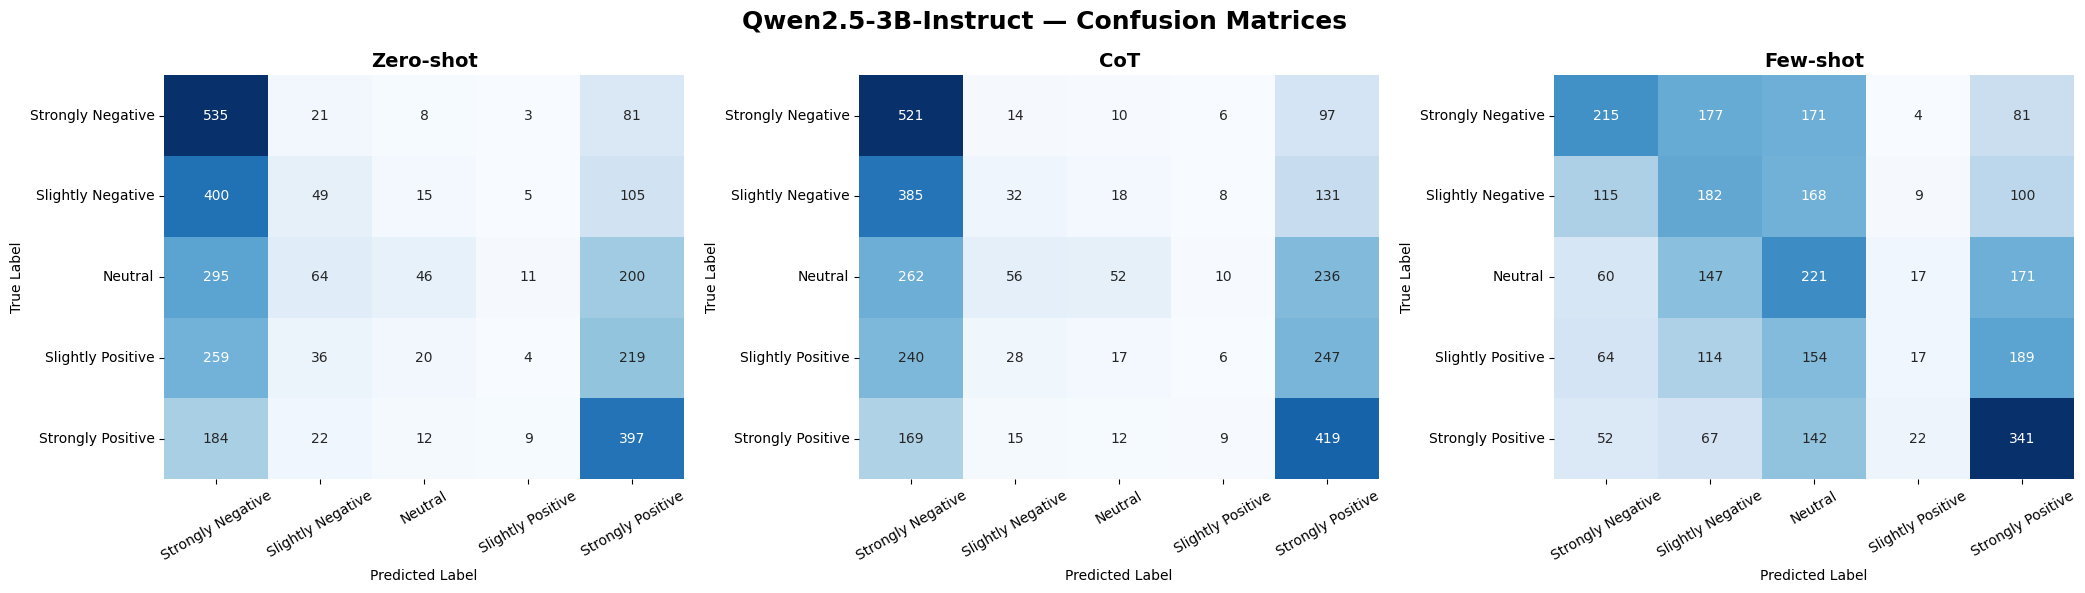

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = [
    "Strongly Negative",
    "Slightly Negative",
    "Neutral",
    "Slightly Positive",
    "Strongly Positive"
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

matrices = [
    (zero_cm, "Zero-shot"),
    (cot_cm, "CoT"),
    (few_cm, "Few-shot")
]

for ax, (cm, title) in zip(axes, matrices):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        cbar=False
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Qwen2.5-3B-Instruct — Confusion Matrices",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()